# JUNE 25th-anniversary analysis — Step 6: three specific questions

1. **Which model organisms are featured in JUNE?**
2. **What's the timeline of computational, data-science, and programming labs?**
3. **How are CUREs (course-based undergraduate research experiences)
   featured, over time and by SfN theme?**

**How:** for each organism, kind of computational lab, or SfN theme, the
Settings cell lists the words that signal it.

- **Organisms (Part 1)** are searched in each article's **full text** (the
  PDF, minus its reference list), since many articles name their organism
  only in the methods. One answer per organism: does the article include an
  activity with it (yes/no)?
- **Computational labs and CUREs (Parts 2–3)** are searched in the title,
  keywords, and abstract, at two levels:
- **featured** — the words are in the title or the author keywords
  (the article is *about* it)
- **mentioned** — the words appear anywhere, including the abstract
  (an article may mention rats in passing)

The word lists are easy to read and to change. A search like this misses
articles that use other words, and catches some that use the words in
another sense, so the lists of matched articles are saved for checking.

**What you need to do:** run each cell from top to bottom (about 10 minutes the
first time, while the PDFs download; a minute or so after that).
Then check `hand_checks.csv` (see "Hand checks" below) and run again.

**What goes in:** `data/june_matched.csv` (from Step 2), `hand_checks.csv`, and the
article PDFs (downloaded into `pdfs/` the first time; about 200 MB, ~10 minutes)

**What comes out:** figures 5–7 in `figures/`, tables 8–11 in `tables/`,
and the matched-article lists in `data/`

## Running in Google Colab

If you opened this notebook from the "Open in Colab" link, run the next cell
first. It downloads the project's files from GitHub (the CSVs from earlier
steps and `manual_fixes.csv`) so the rest of the notebook can find them.
On your own computer, the cell does nothing.

**Colab forgets everything when the session ends.** To keep a result, download
it from the Files panel (folder icon on the left). Make hand corrections in
`manual_fixes.csv` on GitHub, not in Colab, so they aren't lost.

In [1]:
import os
import subprocess
import sys

if "google.colab" in sys.modules and not os.path.exists("manual_fixes.csv"):
    if not os.path.exists("JUNE_Utilities"):
        subprocess.run(["git", "clone", "https://github.com/ajuavinett/JUNE_Utilities.git"], check=True)
    os.chdir("JUNE_Utilities")
    print("Working in", os.getcwd())

## Settings — the only cell you should normally need to edit

In [2]:
MATCHED_CSV = "data/june_matched.csv"
# The hand-check file, shared with Step 7: one row per article (see "Hand checks" below)
HAND_CHECKS_CSV = "hand_checks.csv"

# Which kinds of items to search (same as Step 4). Workshop articles are included.
ITEM_TYPES = ["article", "case study", "technical"]

# Eras, as ranges of volumes (same as Step 4)
ERAS = [(1, 5), (6, 10), (11, 15), (16, 20), (21, 24)]

# Each organism and the words that signal it. These are "regular expressions":
#   |   means "or"          \b  means a word boundary ("\brats?\b" = "rat" or "rats", not "pirates")
#   ?   means "optional"    capitalization never matters
# Anything counts as an activity with an organism: live animals or behavior,
# dissections and tissue, data or images from it, humans as participants,
# and plants and algae (decided 2026-10-03).
ORGANISMS = {
    "Rat": r"\brats?\b",
    # (not a computer mouse — "mouse click", "mouse button", … — and not the animal an
    #  antibody was made in — "mouse monoclonal", "anti-mouse", …)
    "Mouse": r"\bmice\b|murine|(?<!computer )(?<!anti-)(?<!anti )\bmouse\b(?! ?(?:click|button|pointer|cursor|over|wheel|pad))(?![‐-]? ?(?:monoclonal|anti\b|anti-|igg))",
    "Other rodents": r"hamster|gerbil|guinea pig|\bvoles?\b|\brodents?\b",
    "Drosophila (fruit fly)": r"drosophila|fruit ?fl(?:y|ies)",
    "C. elegans": r"c\. ?elegans|caenorhabditis|nematode",
    "Zebrafish": r"zebrafish|danio",
    # (not just "fish": zebrafish articles call them "the fish" too)
    "Other fish": r"goldfish|cichlid|stickleback|\bbettas?\b|fighting fish|killifish|guppy|guppies|electric fish|weakly electric",
    "Crayfish": r"crayfish",
    "Other crustaceans": r"\bcrabs?\b|lobster|shrimp|daphnia|crustacean",
    "Cockroach": r"cockroach",
    "Cricket": r"\bcrickets?\b",
    "Honey bee": r"\bbees?\b|honey ?bee",
    "Other insects": r"locust|grasshopper|\bmoths?\b|manduca|butterfl|beetle|\binsects?\b",
    "Leech": r"\bleech",
    "Aplysia / sea slug": r"aplysia|sea slug|sea hare",
    "Squid / octopus": r"\bsquid|octopus|cephalopod",
    "Snail": r"snail|lymnaea|helix aspersa",
    "Planaria": r"planari",
    "Earthworm": r"earthworm|lumbricus",
    "Other invertebrates": r"\bhydra\b|jellyfish|sea urchin|limulus|horseshoe crab|tardigrade|\binvertebrates?\b",
    "Frog / Xenopus": r"xenopus|\bfrogs?\b|tadpole|\btoads?\b",
    "Salamander / axolotl": r"salamander|axolotl|\bnewts?\b",
    "Reptiles": r"turtle|lizard|\banoles?\b|\bsnakes?\b|gecko",
    "Chick / birds": r"\bchicks?\b|chicken|zebra finch|songbird|pigeon|\bquail|\bbirds?\b",
    "Sheep / pig / cow": r"\bsheep\b|\bpigs?\b|porcine|\bcows?\b|bovine",
    "Cat / dog": r"\bcats?\b|\bfeline\b|\bdogs?\b|\bcanine\b",
    "Non-human primates": r"monkey|non-?human primate|macaque|chimpanzee",
    "Plants & algae": r"\bchara\b|nitella|\balga(?:e|l)\b|venus fly ?trap|dionaea|mimosa|\bplants?\b",
}

# Humans count only as "Students as their own subjects": lab activities where
# students experiment on themselves or each other (lab partners, classmates) —
# not analyzing existing human data, and not students testing other people
# (e.g., outreach participants). Decided 2026-10-04.
# An article is *suggested* if it names a self-measurement method at least
# MIN_MENTIONS times AND either has words showing students are the subjects,
# or names the methods at least 10 times along with "subjects"/"participants"
# (EEG and EMG labs often just say "the subject"). Articles mostly about
# outreach are not suggested. Checked against 72 hand-sorted articles, this
# finds 35 of 36 real self-experiment labs but also suggests 14 that aren't,
# so people confirm each one in HAND_CHECKS_CSV.
SELF_MEASUREMENT_METHODS = (r"\beeg\b|electroencephalogra|\bemg\b|electromyogra|\becg\b|\bekg\b|"
                            r"electrocardiogra|heart rate|reaction times?\b|psychophysic|illusion|\btaste\b|"
                            r"cortisol|blood glucose|skin conductance|galvanic skin|\bgsr\b|blood pressure|"
                            r"eye[- ]tracking|stroop|two-point discrimination|\breflex(?:es)?\b")
STUDENTS_AS_SUBJECTS = (r"students? (?:served|acted|participated|volunteered) as|on themselves|themselves as|"
                        r"each other|one another|lab partners?|(?:their|a) partner|"
                        r"(?:their|her|his) own (?:eeg|emg|ecg|heart|reaction|brain|muscles?|bod(?:y|ies)|"
                        r"physiolog|saliva|blood|taste|perception|responses?)|student (?:subjects?|participants?)|"
                        r"students? as (?:subjects|participants)|(?:one|another) student (?:served|acted|was)|"
                        r"electrodes? (?:were |was )?(?:placed|attached) (?:on|to)")
SUBJECT_WORDS = r"\bsubjects?\b|\bparticipants?\b|\bvolunteers?\b"
OUTREACH_WORDS = r"middle school|high school students|sixth grade|preschool|elementary|k-12|outreach"
# An organism counts as an activity if its words appear at least this many
# times in the article's text (reference list removed), or at all in the
# title or keywords. One or two passing mentions in an introduction don't count.
MIN_MENTIONS = 3

# Where the article PDFs are kept (not uploaded to GitHub; see .gitignore)
PDF_DIR = "pdfs"
SECONDS_BETWEEN_DOWNLOADS = 1.0   # be polite to funjournal.org

# PDFs put in PDF_DIR by hand, for articles with no PDF link on funjournal.org.
# Format: item_id: (start of the title, file name in PDF_DIR). The title is a
# safety check: if item IDs ever shift, the notebook warns instead of using
# the wrong file.
PDFS_ADDED_BY_HAND = {
    "JUNE-10-1-14": ("A Modified Golgi-Cox Procedure", "10-1_Wright_10_1_A85_A87.pdf"),  # from the JUNE Drive archive
}

# Kinds of computational / data-science / programming labs
COMPUTATIONAL = {
    "Simulations & models": r"simulat|computational model|computer model|neurons in action|swimmy|metaneuron|hodgkin|neural network",
    "Programming & coding": r"python|matlab|programming|\bcoding\b|jupyter|rstudio|\br programming|arduino|raspberry pi",
    "Open data & databases": r"open data|open[- ]access data|allen (?:brain|cell|institute)|database|neuroinformatics|bioinformatics|big data|data science|neuromorpho|openneuro",
    "Image & data-analysis software": r"imagej|\bfiji\b|image analysis|spike sort|machine learning",
}

# How a CURE is recognized
CURE_WORDS = r"\bcures?\b|course[- ]based (?:undergraduate )?research"

# SfN's abstract themes (the 2025 list; before 2025 there were 10 themes, A–J).
# The words are only used to *suggest* themes; people decide (Part 3).
# Theme K (History, Education, and Society) applies to every CURE, so it isn't suggested.
SFN_THEMES = {
    # (not plain "development", which also matches "professional development")
    "A": ("Development", r"neurodevelop|developmental|embryo|neurogenesis|axon guidance|neuronal differentiation"),
    "B": ("Neural Excitability, Synapses, and Glia", r"synap|action potential|ion channel|neurotransmi|\bglia|astrocyte|excitab|membrane potential|receptor"),
    "C": ("Neural Aging and Degeneration", r"\baging\b|\bageing\b|alzheimer|parkinson|neurodegenerat|huntington"),
    # (not "immun", which also matches immunohistochemistry, a technique)
    "D": ("Neuroimmunity, Neurovasculature, and Neural Injury", r"neuroimmun|immune|immunolog|inflamm|injury|stroke"),
    "E": ("Sensory Systems", r"sensory|\btaste|visual|vision|auditory|olfact|\btouch|\bpain\b|retina|somatosens"),
    "F": ("Motor Systems", r"\bmotor\b|locomot|escape|movement|muscle"),
    "G": ("Integrative Physiology and Behavior", r"behavio|\bstress|sleep|hormone|cortisol|circadian|feeding|social|aggression|courtship|vagal|autonomic|sex differences"),
    "H": ("Motivation and Emotion", r"reward|addiction|\bfear|anxiety|emotion|motivation"),
    "I": ("Cognition", r"memory|cognit|attention|decision|language"),
    "J": ("Techniques", r"optogenetic|imaging|microscop|immunohisto|rnai|crispr|genotyp|\beeg\b|staining|neuroanatom|electrophysiolog"),
    "K": ("History, Education, and Society", None),
}

FIGURES_DIR = "figures"
TABLES_DIR = "tables"

## Setup (no need to edit below this line)

In [3]:
import os
import re
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MaxNLocator

warnings.filterwarnings("ignore", message="This pattern is interpreted as a regular expression")
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)

articles = pd.read_csv(MATCHED_CSV, keep_default_na=False, dtype=str, encoding="utf-8-sig")
articles = articles[articles["item_type"].isin(ITEM_TYPES)].reset_index(drop=True)
articles["volume"] = articles["volume"].astype(int)
articles["year_label"] = articles["year_label"].astype(int)
# Text to search: title + keywords ("featured"), and that plus the abstract ("mentioned")
articles["featured_text"] = (articles["title"] + " ; " + articles["keywords"]).str.lower()
articles["all_text"] = (articles["featured_text"] + " ; " + articles["abstract"]).str.lower()


def era_of(volume):
    for first, last in ERAS:
        if first <= volume <= last:
            years = articles.loc[articles["volume"].between(first, last), "year_label"]
            return f"Vol {first}–{last} ({years.min()}–{years.max()})"
    return ""


articles["era"] = articles["volume"].map(era_of)
ERA_ORDER = list(dict.fromkeys(articles.sort_values("volume")["era"]))
print(f"{len(articles)} items ({', '.join(ITEM_TYPES)}), volumes "
      f"{articles['volume'].min()}–{articles['volume'].max()}")


def find(patterns):
    """For each name in `patterns`, which articles feature it and which mention it."""
    featured = pd.DataFrame({name: articles["featured_text"].str.contains(p) for name, p in patterns.items()})
    mentioned = pd.DataFrame({name: articles["all_text"].str.contains(p) for name, p in patterns.items()})
    return featured, mentioned


def first_featured(featured, name):
    """Where and when `name` was first featured: ("volume(issue), year", title)."""
    hits = articles[featured[name]].sort_values(["volume", "issue"])
    if hits.empty:
        return "", ""
    first = hits.iloc[0]
    return f"{first['volume']}({first['issue']}), {first['year_label']}", first["title"]


# Shared figure style (Arial, Okabe–Ito colors, font sizes): see june.mplstyle
plt.style.use("june.mplstyle")
BLUE = "#0072B2"

# ---- The hand-check file, shared by Steps 6 and 7: one row per article ----
# Each question has a "(suggested)" column, refreshed on every run, and a column
# people fill in only to correct the suggestion. People's columns are never changed.
HAND_CHECK_COLUMNS = [
    "item_id", "volume", "issue", "year", "title", "checked", "note",
    "organisms (suggested)", "organisms",
    "computational (suggested)", "computational",
    "CURE (suggested)", "CURE", "CURE themes (suggested)", "CURE themes",
    "topics (suggested)", "topics",
    "organisms: times named", "organisms: self-experiment evidence",
    "computational: in abstract only", "topics: matched words",
]


def read_hand_checks():
    if os.path.exists(HAND_CHECKS_CSV):
        return pd.read_csv(HAND_CHECKS_CSV, keep_default_na=False, dtype=str)
    return pd.DataFrame(columns=HAND_CHECK_COLUMNS)


def update_hand_checks(refreshed):
    """Write this notebook's suggestion columns (a table indexed by item_id) into HAND_CHECKS_CSV."""
    checks = read_hand_checks()
    new = articles.loc[~articles["item_id"].isin(checks["item_id"]), ["item_id"]]
    if len(new):
        checks = pd.concat([checks, new], ignore_index=True)
        print(f"Added {len(new)} new article(s) to {HAND_CHECKS_CSV}")
    by_id = articles.set_index("item_id")
    info = pd.DataFrame({"volume": by_id["volume"].astype(str), "issue": by_id["issue"],
                         "year": by_id["year_label"].astype(str), "title": by_id["title"]}).join(refreshed)
    for col in info.columns:
        checks[col] = checks["item_id"].map(info[col])
    for col in HAND_CHECK_COLUMNS:
        if col not in checks:
            checks[col] = ""
    checks = checks[HAND_CHECK_COLUMNS + [c for c in checks.columns if c not in HAND_CHECK_COLUMNS]].fillna("")
    checks.to_csv(HAND_CHECKS_CSV, index=False, encoding="utf-8-sig")
    return checks


def decided(checks, column, names):
    """For each article and name, whether it counts: what people wrote in `column`, or else the suggestion."""
    answer = checks[column].str.strip()
    final = answer.where(answer != "", checks[f"{column} (suggested)"]).set_axis(checks["item_id"])
    chosen = final.str.split(";").map(lambda ns: [n.strip() for n in ns if n.strip() and n.strip().lower() != "none"])
    unknown = sorted(set(chosen.explode().dropna()) - set(names))
    if unknown:
        print(f"  ⚠ Not a name from Settings in the {column!r} column of {HAND_CHECKS_CSV} "
              f"(check the spelling): {', '.join(unknown)}")
    return pd.DataFrame({n: articles["item_id"].map(chosen.map(lambda ns, n=n: n in ns)).fillna(False).astype(bool)
                         for n in names})


def checked_by_hand(checks):
    """Which articles (aligned with `articles`) a person has marked checked."""
    done = checks.loc[checks["checked"].str.strip().str.lower() == "yes", "item_id"]
    return articles["item_id"].isin(done)
TEXT, TEXT_2, SURFACE = "#0b0b0b", "#404040", "#ffffff"


def save(fig, name):
    for ext in ("png", "pdf"):
        fig.savefig(os.path.join(FIGURES_DIR, f"{name}.{ext}"), metadata={"CreationDate": None} if ext == "pdf" else None)
    print(f"saved {FIGURES_DIR}/{name}.png and .pdf")


def save_table(df, name, index=False):
    df.to_csv(os.path.join(TABLES_DIR, f"{name}.csv"), index=index, encoding="utf-8-sig")
    print(f"saved {TABLES_DIR}/{name}.csv")

508 items (article, case study, technical), volumes 1–24


## Hand checks: `hand_checks.csv`

One file, shared with Step 7, where people check everything the word searches
suggest. It has **one row per article**, so you can scroll through and check
an article's organisms, computational labs, CURE status, and topics at once.

For each question there are two columns:
- `… (suggested)` — what the word search suggests. **Refreshed on every run**,
  so improving the word lists in Settings updates it.
- the answer column (`organisms`, `computational`, `CURE`, `CURE themes`,
  `topics`) — **leave it empty to accept the suggestion.** To correct it,
  write what's right, separated by "; " and spelled as in Settings, or
  `none` if nothing applies. Whatever is written here replaces the suggestion.

Plus, for the whole row:
- `checked` — write `yes` once a person has checked the row.
- `note` — anything worth remembering.

The last columns help decide: how many times each organism is named, the
phrase suggesting students are their own subjects, kinds of computational
lab named only in the abstract, and the words behind each topic.

Later runs never change `checked`, `note`, or the answer columns; new
articles are added at the bottom.

## Part 1: model organisms

### 1a. Get each article's full text

- **PDF:** downloaded from funjournal.org into `pdfs/` (named like
  `14-1_june-14-29.pdf`: volume-issue, then the original file name), and its
  text read with `pypdf`. Downloaded once; later runs reuse the files.
- **Scholastica articles** (volume 24 on) have no PDF link; their web page
  has the full text.
- **PDFs added by hand** (listed in `PDFS_ADDED_BY_HAND` in Settings) are
  used for articles with no PDF link, e.g. one found in the JUNE Drive archive.
- If none of these works, we fall back to the title, keywords, and abstract.

Then the reference list is cut off (everything after the last "References"
heading), so an article that only *cites* a mouse study doesn't count as a
mouse activity.

In [4]:
import hashlib
import time

import requests
from bs4 import BeautifulSoup
from pypdf import PdfReader

HEADERS = {"User-Agent": "JUNE-25th-anniversary-analysis (academic, non-commercial)"}
TEXT_CACHE_DIR = os.path.join("cache", "fulltext")
os.makedirs(PDF_DIR, exist_ok=True)
os.makedirs(TEXT_CACHE_DIR, exist_ok=True)


def pdf_file(row):
    original_name = row["pdf_url"].rstrip("/").split("/")[-1]
    return os.path.join(PDF_DIR, f"{row['volume']:02d}-{row['issue']}_{original_name}")


def download(url, path):
    """Download a PDF once (later runs reuse it). Returns True if we have it."""
    if os.path.exists(path):
        return True
    for attempt in range(1, 4):
        time.sleep(SECONDS_BETWEEN_DOWNLOADS * attempt)
        try:
            resp = requests.get(url, headers=HEADERS, timeout=60)
            resp.raise_for_status()
            if not resp.content.startswith(b"%PDF"):
                raise ValueError("the link didn't return a PDF")
            with open(path, "wb") as f:
                f.write(resp.content)
            return True
        except Exception as e:
            problem = e
    print(f"  ✗ couldn't download {url}: {problem}")
    return False


def text_from_pdf(path):
    """The PDF's text (saved in cache/fulltext/ so it's only read once)."""
    saved = os.path.join(TEXT_CACHE_DIR, os.path.basename(path) + ".txt")
    if os.path.exists(saved):
        with open(saved, encoding="utf-8") as f:
            return f.read()
    try:
        text = "\n".join(page.extract_text() or "" for page in PdfReader(path).pages)
    except Exception as e:
        print(f"  ✗ couldn't read {path}: {e}")
        text = ""
    with open(saved, "w", encoding="utf-8") as f:
        f.write(text)
    return text


def text_from_web_page(url):
    """A web page's text. Re-uses Step 1's saved copy in cache/ when there is one."""
    saved = os.path.join("cache", hashlib.md5(url.encode()).hexdigest() + ".html")
    if os.path.exists(saved):
        with open(saved, encoding="utf-8") as f:
            html = f.read()
    else:
        time.sleep(SECONDS_BETWEEN_DOWNLOADS)
        html = requests.get(url, headers=HEADERS, timeout=60).text
        with open(saved, "w", encoding="utf-8") as f:
            f.write(html)
    soup = BeautifulSoup(html, "lxml")
    for junk in soup(["script", "style", "noscript", "nav", "header", "footer"]):
        junk.decompose()
    return soup.get_text("\n")


REFERENCES_HEADING = re.compile(r"^\s*(?:references?|literature cited|bibliography|works cited)\s*:?\s*$",
                                re.IGNORECASE | re.MULTILINE)


def without_references(text):
    """Everything before the reference list.

    Uses the last "References" heading on a line of its own. PDF text often
    glues the heading to its neighbors ("…questions.referencesAiken DE…"),
    so if there's no such heading, it uses the last "references" in the
    second half of the text instead."""
    headings = list(REFERENCES_HEADING.finditer(text))
    if headings:
        return text[:headings[-1].start()], True
    glued = [m.start() for m in re.finditer(r"references|literature cited|bibliography", text, re.IGNORECASE)
             if m.start() > len(text) / 2]
    return (text[:glued[-1]], True) if glued else (text, False)


texts, sources, cut = [], [], []
for n, (_, row) in enumerate(articles.iterrows(), 1):
    text, source = "", ""
    by_hand = PDFS_ADDED_BY_HAND.get(row["item_id"])
    if by_hand and not row["title"].lower().startswith(by_hand[0].lower()):
        print(f"  ⚠ {row['item_id']} is now {row['title'][:50]!r}, not {by_hand[0]!r}; "
              f"update PDFS_ADDED_BY_HAND in Settings")
        by_hand = None
    if by_hand and os.path.exists(os.path.join(PDF_DIR, by_hand[1])):
        text, source = text_from_pdf(os.path.join(PDF_DIR, by_hand[1])), "PDF (added by hand)"
    elif row["pdf_url"] and download(row["pdf_url"], pdf_file(row)):
        text, source = text_from_pdf(pdf_file(row)), "PDF"
    elif row["listed_on"] != "funjournal.org" and row["article_page_url"]:
        text, source = text_from_web_page(row["article_page_url"]), "web page"
    if len(text.split()) < 300:          # nothing usable (e.g., a scanned PDF)
        text, source = row["title"] + "\n" + row["keywords"] + "\n" + row["abstract"], "abstract only"
    text, removed = without_references(text)
    texts.append(text.lower())
    sources.append(source)
    cut.append(removed)
    if n % 100 == 0:
        print(f"  {n} of {len(articles)} articles read")

articles["full_text"] = texts
articles["text_source"] = sources
articles["references_removed"] = cut
print(articles["text_source"].value_counts().to_string())
print(f"Reference list found and removed in {sum(cut)} of {len(articles)} articles")

  100 of 508 articles read
  200 of 508 articles read
  300 of 508 articles read


  400 of 508 articles read


  500 of 508 articles read
text_source
PDF                    489
web page                18
PDF (added by hand)      1
Reference list found and removed in 498 of 508 articles


### 1b. Which articles include an activity with each organism

An article includes an activity with an organism if the organism's words
appear in its title or keywords, or at least `MIN_MENTIONS` times in its
text. `data/organism_articles.csv` lists every article with how many times
each organism was named, so borderline cases are easy to check.

**Humans** count only as **"Students as their own subjects"**: lab activities
where students experiment on themselves or each other. An article is
*suggested* if it names a self-measurement method (EEG, EMG, heart rate,
reaction time, illusions, taste, cortisol, …) at least `MIN_MENTIONS` times
and has words showing students are the subjects ("on themselves",
"lab partners", "student volunteers", …). Analyzing existing human data and
students testing other people don't count.

**Hand check:** the `organisms` columns of `hand_checks.csv` (see "Hand
checks" above). `organisms: times named` and `organisms: self-experiment
evidence` help decide.

Figure 5 shows how many articles include an activity with each organism.

hand_checks.csv: 1 of 508 articles checked by hand
saved tables/table8_model_organisms.csv
215 of 508 articles (42%) include an activity with at least one organism; 73 with more than one.


saved figures/fig5_model_organisms.png and .pdf


,articles with an activity,first appears,first appears in,Vol 1–5 (2002–2007),Vol 6–10 (2007–2012),Vol 11–15 (2012–2017),Vol 16–20 (2017–2022),Vol 21–24 (2022–2026)
organism,,,,,,,,
Students as their own subjects,58,"1(2), 2003",Testing the Relationship Between Levels of End...,5,9,15,17,12
Mouse,41,"2(1), 2003",Experimental Methods in Neuroscience: An Under...,2,12,9,16,2
Rat,38,"1(1), 2002",The Emergence of Non-Match-to-Sample Behavior ...,13,12,4,8,1
Drosophila (fruit fly),22,"4(1), 2005",Demonstrating the Temperature Sensitivity of S...,2,3,5,9,3
Crayfish,18,"1(1), 2002",Exploring Neurogenesis in Crustaceans,4,5,4,5,0
Other insects,15,"6(1), 2007",Technical Note: Construction of a Simple Sucti...,0,2,9,4,0
Sheep / pig / cow,14,"8(1), 2009",Vision and Art: An Interdisciplinary Approach ...,0,4,1,7,2
Other rodents,13,"2(2), 2004",Ultrasonic Courtship Vocalizations of Adult Ma...,1,4,4,4,0
Other invertebrates,11,"1(1), 2002",Exploring Neurogenesis in Crustaceans,3,1,3,3,1


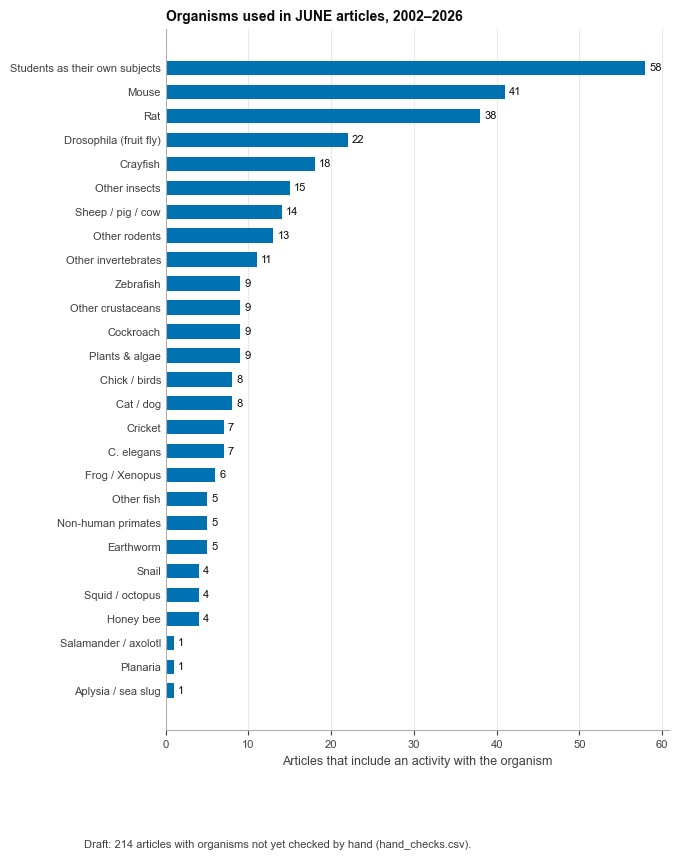

In [5]:
mention_counts = pd.DataFrame({name: articles["full_text"].str.count(words) for name, words in ORGANISMS.items()})
in_title_or_keywords = pd.DataFrame({name: articles["featured_text"].str.contains(words)
                                     for name, words in ORGANISMS.items()})
has_activity = (mention_counts >= MIN_MENTIONS) | in_title_or_keywords

# Students as their own subjects (see SELF_MEASUREMENT_METHODS in Settings)
method_mentions = articles["full_text"].str.count(SELF_MEASUREMENT_METHODS)
students_are_subjects = articles["full_text"].str.contains(STUDENTS_AS_SUBJECTS)
mention_counts["Students as their own subjects"] = method_mentions
in_title_or_keywords["Students as their own subjects"] = False
has_activity["Students as their own subjects"] = (
    (method_mentions >= MIN_MENTIONS)
    & (students_are_subjects | ((method_mentions >= 10) & articles["full_text"].str.contains(SUBJECT_WORDS)))
    & (articles["full_text"].str.count(OUTREACH_WORDS) < 5))


def evidence(text):
    """The first phrase showing students are the subjects, with a little context."""
    m = re.search(STUDENTS_AS_SUBJECTS, text)
    return text[max(0, m.start() - 60):m.end() + 60].replace("\n", " ") if m else ""


# ---- Suggestions into the hand-check file; the "organisms" column decides ----
checks = update_hand_checks(pd.DataFrame({
    "organisms (suggested)": has_activity.apply(lambda r: "; ".join(r.index[r]), axis=1),
    "organisms: times named": mention_counts.apply(lambda r: "; ".join(f"{k} {v}" for k, v in r.items() if v > 0), axis=1),
    "organisms: self-experiment evidence": [evidence(t) if s else "" for t, s in
                                            zip(articles["full_text"], has_activity["Students as their own subjects"])],
}).set_axis(articles["item_id"]))
has_activity = decided(checks, "organisms", list(has_activity.columns))
checked = checked_by_hand(checks)
print(f"{HAND_CHECKS_CSV}: {checked.sum()} of {len(checks)} articles checked by hand")

# Every article with any organism named, and how many times
listing = articles[["item_id", "volume", "issue", "year_label", "title", "text_source"]].copy()
listing["organisms (activity)"] = has_activity.apply(lambda r: "; ".join(r.index[r]), axis=1)
listing = pd.concat([listing, mention_counts.add_prefix("times named: ")], axis=1)
listing[mention_counts.sum(axis=1) > 0].to_csv("data/organism_articles.csv", index=False, encoding="utf-8-sig")


def first_activity(name):
    hits = articles[has_activity[name]].sort_values(["volume", "issue"])
    if hits.empty:
        return "", ""
    first = hits.iloc[0]
    return f"{first['volume']}({first['issue']}), {first['year_label']}", first["title"]


table8 = pd.DataFrame({"articles with an activity": has_activity.sum()})
table8["first appears"] = [first_activity(n)[0] for n in table8.index]
table8["first appears in"] = [first_activity(n)[1] for n in table8.index]
by_era = pd.DataFrame({era: has_activity[articles["era"] == era].sum() for era in ERA_ORDER})
table8 = pd.concat([table8, by_era], axis=1).sort_values("articles with an activity", ascending=False)
table8.index.name = "organism"
save_table(table8, "table8_model_organisms", index=True)

any_organism = has_activity.any(axis=1)
print(f"{any_organism.sum()} of {len(articles)} articles ({100 * any_organism.mean():.0f}%) include an activity "
      f"with at least one organism; {(has_activity.sum(axis=1) > 1).sum()} with more than one.")

plot = table8[table8["articles with an activity"] > 0]["articles with an activity"][::-1]
fig, ax = plt.subplots(figsize=(6.5, 0.3 * len(plot) + 1))
ax.barh(plot.index, plot.values, height=0.6, color=BLUE)
for y, n in enumerate(plot.values):
    ax.text(n + 0.5, y, str(n), va="center", fontsize=8, color=TEXT)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.tick_params(axis="y", length=0)
ax.set_xlabel("Articles that include an activity with the organism")
ax.set_title("Organisms used in JUNE articles, 2002–2026")
needs_check = has_activity.any(axis=1) & ~checked
if needs_check.any():
    fig.text(0, -0.02, f"Draft: {needs_check.sum()} articles with organisms not yet checked by hand "
             f"({HAND_CHECKS_CSV}).", color=TEXT_2, fontsize=8)
save(fig, "fig5_model_organisms")
table8

## Part 2: computational, data-science, and programming labs

For each kind of lab: how many articles feature it, when it was first
featured, and in which volumes. Figure 6 is a timeline: each dot is a
volume, and bigger dots mean more articles featuring that kind of lab.

**Hand check:** the `computational` columns of `hand_checks.csv` (see "Hand
checks" above). Only kinds in the title or keywords are suggested;
`computational: in abstract only` lists kinds named only in the abstract,
which count only if you add them.

71 computational articles; 71 not yet checked by hand
saved tables/table9_computational_labs.csv
saved tables/table9b_computational_by_volume.csv


saved figures/fig6_computational_timeline.png and .pdf


,articles,mentioned only (word search),first featured,first featured in
kind of lab,,,,
Simulations & models,29,17,"2(1), 2003",An Online Multimedia Resource in Behavioral Ne...
Programming & coding,21,18,"4(2), 2006",Responses to Sounds in the Central Auditory Sy...
Open data & databases,19,8,"5(1), 2006",Functional Magnetic Resonance Imaging (fMRI): ...
Image & data-analysis software,8,2,"1(2), 2003",Integrated Undergraduate Research Experience f...


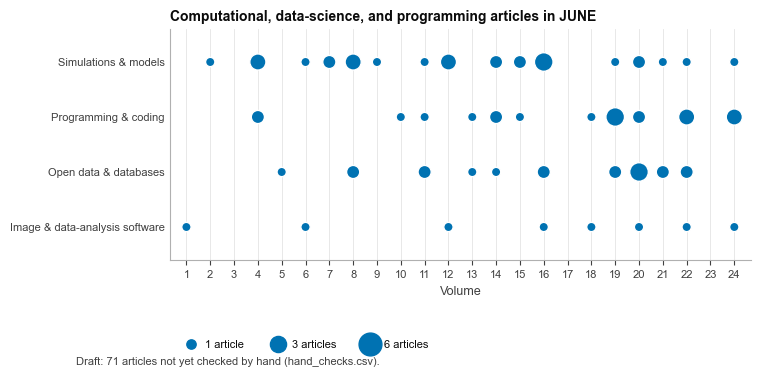

In [6]:
comp_featured, comp_mentioned = find(COMPUTATIONAL)
names_of = lambda df: df.apply(lambda r: "; ".join(r.index[r]), axis=1)
checks = update_hand_checks(pd.DataFrame({
    "computational (suggested)": names_of(comp_featured),
    "computational: in abstract only": names_of(comp_mentioned & ~comp_featured),
}).set_axis(articles["item_id"]))
comp_counted = decided(checks, "computational", list(COMPUTATIONAL))
any_comp = comp_counted.any(axis=1)
comp_unchecked = any_comp & ~checked_by_hand(checks)
print(f"{any_comp.sum()} computational articles; {comp_unchecked.sum()} not yet checked by hand")

table9 = pd.DataFrame({
    "articles": comp_counted.sum(),
    "mentioned only (word search)": (comp_mentioned & ~comp_featured).sum(),
})
table9["first featured"] = [first_featured(comp_counted, n)[0] for n in table9.index]
table9["first featured in"] = [first_featured(comp_counted, n)[1] for n in table9.index]
per_volume = pd.DataFrame({n: comp_counted[n].groupby(articles["volume"]).sum() for n in COMPUTATIONAL})
per_volume["any of these"] = any_comp.groupby(articles["volume"]).sum()
per_volume["all articles in volume"] = articles.groupby("volume").size()
per_volume["% of volume's articles"] = (100 * per_volume["any of these"] / per_volume["all articles in volume"]).round(1)
table9.index.name = "kind of lab"
save_table(table9, "table9_computational_labs", index=True)
save_table(per_volume, "table9b_computational_by_volume", index=True)

fig, ax = plt.subplots(figsize=(7.5, 3))
names = list(COMPUTATIONAL)[::-1]
for y, name in enumerate(names):
    counts = per_volume[name]
    counts = counts[counts > 0]
    ax.scatter(counts.index, [y] * len(counts), s=counts * 45, color=BLUE, edgecolor=SURFACE, linewidth=1, zorder=3)
ax.set_yticks(range(len(names)), names)
ax.set_xticks(range(1, articles["volume"].max() + 1))
ax.set_xlim(0.3, articles["volume"].max() + 0.7)
ax.set_ylim(-0.6, len(names) - 0.4)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.tick_params(axis="y", length=0)
ax.set_xlabel("Volume")
ax.set_title("Computational, data-science, and programming articles in JUNE")
for n in (1, 3, 6):
    ax.scatter([], [], s=n * 45, color=BLUE, label=f"{n} article{'s' if n > 1 else ''}")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.3), ncols=3, scatterpoints=1, handletextpad=0.3)
if comp_unchecked.sum():
    fig.text(0, -0.24, f"Draft: {comp_unchecked.sum()} articles not yet checked by hand ({HAND_CHECKS_CSV}).",
             color=TEXT_2, fontsize=8)
save(fig, "fig6_computational_timeline")
table9

In [7]:
# The same, volume by volume
per_volume

,Simulations & models,Programming & coding,Open data & databases,Image & data-analysis software,any of these,all articles in volume,% of volume's articles
volume,,,,,,,
1,0,0,0,1,1,8,12.5
2,1,0,0,0,1,9,11.1
3,0,0,0,0,0,11,0.0
4,3,2,0,0,4,11,36.4
5,0,0,1,0,1,11,9.1
6,1,0,0,1,2,12,16.7
7,2,0,0,0,2,12,16.7
8,3,0,2,0,5,26,19.2
9,1,0,0,0,1,15,6.7


## Part 3: CUREs

**Finding CUREs.** An article counts as a CURE if its title or keywords say
"CURE" or "course-based (undergraduate) research". Articles that only use
those words in the abstract are listed too, as *possible* CUREs: some describe
a CURE, others only mention CUREs in passing. CUREs described in other words
(especially before the term caught on, around 2015) can't be found this way
and need to be added by hand.

**Hand check:** the `CURE` and `CURE themes` columns of `hand_checks.csv`
(see "Hand checks" above).
- `CURE (suggested)` is `yes` if the title or keywords name a CURE, and
  `maybe` if only the abstract does. `yes` counts; `maybe` doesn't. Write
  `yes` or `no` in `CURE` to decide. For a CURE the search missed, write
  `yes` in its row.
- `CURE themes (suggested)` lists SfN theme letters from the word lists in
  Settings (e.g., `G; J`); correct them in `CURE themes`.

15 CUREs (0 checked by hand); 9 candidates not counted
saved tables/table10_cures.csv
saved tables/table11_cure_themes.csv


saved figures/fig7_cures.png and .pdf


,item_id,volume,issue,year_label,title,themes,checked
315,JUNE-17-1-03,17,1,2018,Analysis of Student Attitudes of a Neurobiolog...,F,
328,JUNE-17-1-16,17,1,2018,Classroom-Based Research Experiences to Suppor...,A; J,
340,JUNE-18-1-03,18,1,2019,Cognitive and Non-Cognitive Outcomes Associate...,H; I; J,
344,JUNE-18-1-07,18,1,2019,Versatile Undergraduate Neurobiology Course-Ba...,B; J,
349,JUNE-18-2-04,18,2,2020,Chick Embryonic Primary Astrocyte Cultures Pro...,A; B; I,
357,JUNE-19-1-03,19,1,2020,Dissecting the Molecular and Neural Circuit Ba...,E; G,
361,JUNE-19-1-07,19,1,2020,Integrating Research into the Undergraduate Cu...,,
376,JUNE-19-2-08,19,2,2021,"Assessment of Mapping the Brain , a Novel Rese...",B,
377,JUNE-19-2-09,19,2,2021,A Course-Based Research Experience Using the A...,J,
382,JUNE-20-1-07,20,1,2021,"The Spine Lab: A Short-Duration, Fully-Remote ...",B,


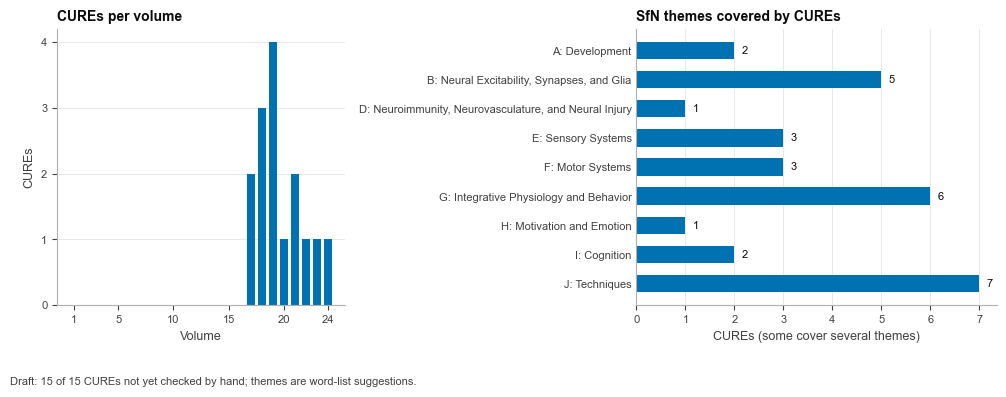

In [8]:
named = articles["featured_text"].str.contains(CURE_WORDS)
in_abstract = articles["all_text"].str.contains(CURE_WORDS) & ~named


def suggest_themes(text):
    return "; ".join(letter for letter, (_, words) in SFN_THEMES.items() if words and re.search(words, text))


# Themes are suggested for candidates, and for articles people have marked as CUREs
before = read_hand_checks()
marked = before.loc[before["CURE"].str.strip().str.lower() == "yes", "item_id"] if "CURE" in before else []
gets_themes = named | in_abstract | articles["item_id"].isin(marked)
checks = update_hand_checks(pd.DataFrame({
    "CURE (suggested)": ["yes" if n else "maybe" if a else "" for n, a in zip(named, in_abstract)],
    "CURE themes (suggested)": [suggest_themes(t) if g else "" for t, g in zip(articles["all_text"], gets_themes)],
}).set_axis(articles["item_id"]))

# Decide which articles are CUREs: a person's yes/no, or else the suggestion
answer = articles["item_id"].map(checks.set_index("item_id")["CURE"].str.strip().str.lower()).fillna("")
odd = sorted(set(answer) - {"", "yes", "no"})
if odd:
    print(f"  ⚠ The CURE column of {HAND_CHECKS_CSV} should be yes, no, or empty; found: {', '.join(odd)}")
is_cure = (answer == "yes") | ((answer == "") & named)
themes = decided(checks, "CURE themes", list(SFN_THEMES))
cures = articles.loc[is_cure, ["item_id", "volume", "issue", "year_label", "title"]].copy()
cures["themes"] = themes[is_cure].apply(lambda r: "; ".join(r.index[r]), axis=1)
cures["checked"] = checked_by_hand(checks)[is_cure].map({True: "yes", False: ""})
print(f"{len(cures)} CUREs ({(cures['checked'] == 'yes').sum()} checked by hand); "
      f"{((named | in_abstract) & ~is_cure).sum()} candidates not counted")

table10 = cures.sort_values(["volume", "issue"])
save_table(table10, "table10_cures")

theme_names = {k: v[0] for k, v in SFN_THEMES.items()}
theme_counts = themes[is_cure].sum().reindex(list(SFN_THEMES), fill_value=0)
table11 = pd.DataFrame({"theme": [f"{k}: {theme_names[k]}" for k in theme_counts.index],
                        "CUREs": theme_counts.values})
save_table(table11, "table11_cure_themes")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), gridspec_kw={"width_ratios": [1, 1.25]})
per_vol = cures.groupby("volume").size().reindex(range(1, articles["volume"].max() + 1), fill_value=0)
axes[0].bar(per_vol.index, per_vol.values, width=0.7, color=BLUE)
axes[0].set_xticks([1, 5, 10, 15, 20, articles["volume"].max()])
axes[0].yaxis.set_major_locator(MaxNLocator(integer=True))   # whole CUREs only
axes[0].set_xlabel("Volume")
axes[0].set_ylabel("CUREs")
axes[0].grid(axis="x", visible=False)
axes[0].set_title("CUREs per volume")
t = table11[table11["CUREs"] > 0][::-1]
axes[1].barh(t["theme"], t["CUREs"], height=0.6, color=BLUE)
for y, n in enumerate(t["CUREs"]):
    axes[1].text(n + 0.15, y, str(n), va="center", fontsize=8)
axes[1].grid(axis="y", visible=False)
axes[1].grid(axis="x", visible=True)
axes[1].tick_params(axis="y", length=0)
axes[1].set_xlabel("CUREs (some cover several themes)")
axes[1].set_title("SfN themes covered by CUREs")
unchecked = (cures["checked"].str.lower() != "yes").sum()
if unchecked:
    fig.text(0, -0.08, f"Draft: {unchecked} of {len(cures)} CUREs not yet checked by hand; themes are word-list suggestions.",
             color=TEXT_2, fontsize=8)
fig.tight_layout()
save(fig, "fig7_cures")
table10